# Análise Exploratória de Dados – Vendas
Inclui limpeza, outliers, valores faltantes e gráficos.

## Importação

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Dataset com ruído, missing e outliers

In [27]:
np.random.seed(42)
n=200
df=pd.DataFrame({
    'data': pd.date_range('2024-01-01', periods=n, freq='D'),
    'produto': np.random.choice(['A','B','C','D'], n),
    'categoria': np.random.choice(['Eletronicos','Casa','Escritorio'], n),
    'preco': np.random.normal(150,40,n),
    'quantidade': np.random.randint(1,6,n),
    'cidade': np.random.choice(['SP','BH','RJ'], n)
})
df.loc[np.random.choice(df.index,10),'preco']=np.nan
df.loc[np.random.choice(df.index,5),'quantidade']=20
df.head()

,data,produto,categoria,preco,quantidade,cidade
0,2024-01-01,C,Escritorio,168.929505,1,RJ
1,2024-01-02,D,Escritorio,147.086843,4,BH
2,2024-01-03,A,Eletronicos,116.128251,3,SP
3,2024-01-04,C,Eletronicos,89.406111,1,SP
4,2024-01-05,C,Casa,132.139402,1,BH


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   data        200 non-null    datetime64[ns]
 1   produto     200 non-null    object        
 2   categoria   200 non-null    object        
 3   preco       190 non-null    float64       
 4   quantidade  200 non-null    int32         
 5   cidade      200 non-null    object        
dtypes: datetime64[ns](1), float64(1), int32(1), object(3)
memory usage: 8.7+ KB


## Missing Values

In [7]:
df.isna().sum()

data           0
produto        0
categoria      0
preco         10
quantidade     0
cidade         0
dtype: int64

### Imputação (preencher preços faltantes por mediana)

In [31]:
df['preco'] = df['preco'].fillna(df['preco'].median())
df.info()
'''
medida de tendência central mais estável
imputação segura em dados sujos
padrão na EDA para preencher valores faltantes
'''

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   data        200 non-null    datetime64[ns]
 1   produto     200 non-null    object        
 2   categoria   200 non-null    object        
 3   preco       200 non-null    float64       
 4   quantidade  200 non-null    int32         
 5   cidade      200 non-null    object        
dtypes: datetime64[ns](1), float64(1), int32(1), object(3)
memory usage: 8.7+ KB


## Criando coluna total_venda

In [41]:
df['total_venda']=(df['preco']*df['quantidade']).round(2)
df.head()

,data,produto,categoria,preco,quantidade,cidade,total_venda
0,2024-01-01,C,Escritorio,168.929505,1,RJ,168.93
1,2024-01-02,D,Escritorio,147.086843,4,BH,588.36
2,2024-01-03,A,Eletronicos,116.128251,3,SP,348.39
3,2024-01-04,C,Eletronicos,89.406111,1,SP,89.41
4,2024-01-05,C,Casa,132.139402,1,BH,132.14


## Outliers – Boxplot

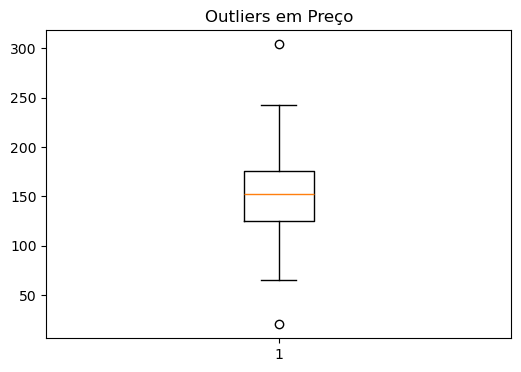

In [43]:
plt.figure(figsize=(6,4))
plt.boxplot(df['preco'])
plt.title('Outliers em Preço')
plt.show()

## Remoção de outliers (quantidade > 10)

In [45]:
df=df[df['quantidade']<=10]
df.shape

(195, 7)

## Faturamento por categoria

In [50]:
df['categoria']

0       Escritorio
1       Escritorio
2      Eletronicos
3      Eletronicos
4             Casa
          ...     
195           Casa
196     Escritorio
197    Eletronicos
198    Eletronicos
199    Eletronicos
Name: categoria, Length: 195, dtype: object

In [47]:
df.groupby('categoria')['total_venda'].sum()

categoria
Casa           26495.06
Eletronicos    28548.32
Escritorio     30886.61
Name: total_venda, dtype: float64

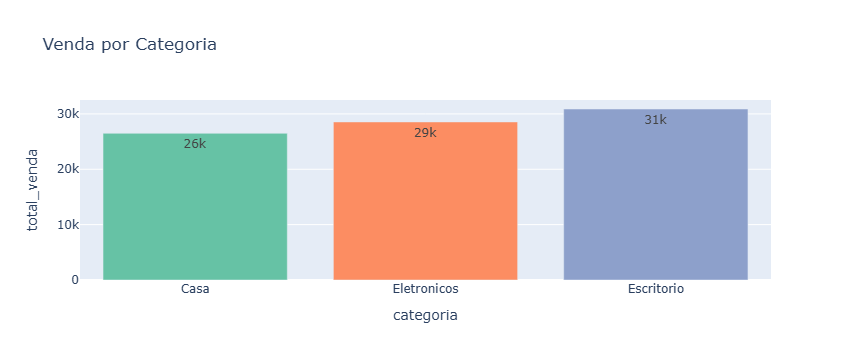

In [80]:
import plotly.express as px

grupo = df.groupby('categoria')['total_venda'].sum().reset_index()

fig = px.bar(
    grupo,
    x='categoria',
    y='total_venda',
    title='Venda por Categoria',
    text_auto='.2s',   # opcional: mostra os valores em cima das barras
    hover_data={'total_venda': ':.2f'}   # tooltip formatado
)
fig.update_traces(marker_color=px.colors.qualitative.Set2)

fig.show()

## Gráfico – Faturamento diário

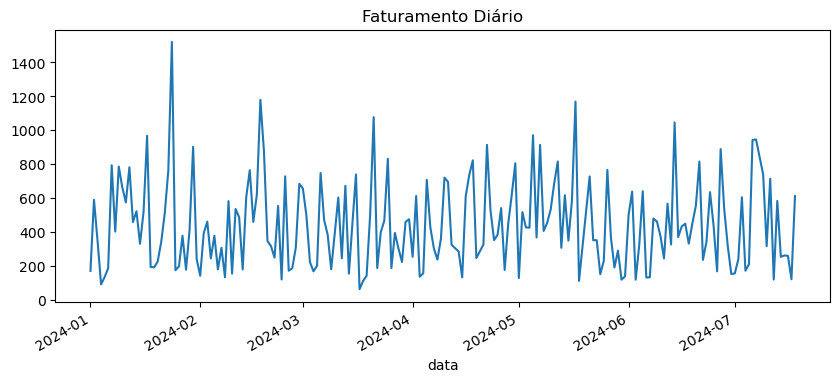

In [52]:
df.groupby('data')['total_venda'].sum().plot(figsize=(10,4))
plt.title('Faturamento Diário')
plt.show()

## Correlação

In [84]:
df[['preco','quantidade','total_venda']].corr()

,preco,quantidade,total_venda
preco,1.000000,-0.003262,0.467229
quantidade,-0.003262,1.000000,0.854562
total_venda,0.467229,0.854562,1.000000


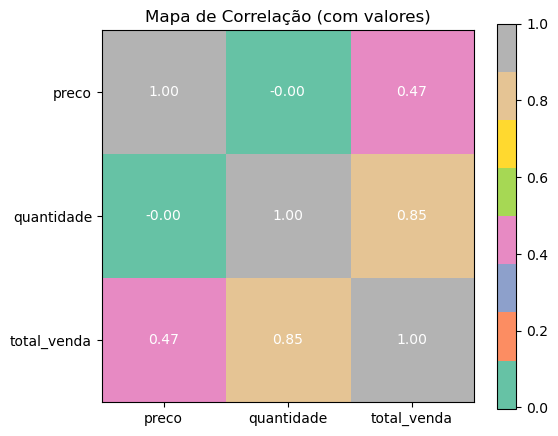

In [92]:
corr = df[['preco','quantidade','total_venda']].corr()
plt.figure(figsize=(6,5))
plt.imshow(corr, cmap='Set2', interpolation='nearest')
plt.colorbar()

plt.xticks(np.arange(len(corr.columns)), corr.columns)
plt.yticks(np.arange(len(corr.columns)), corr.columns)

# adicionando valores
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center', color='white')

plt.title("Mapa de Correlação (com valores)")
plt.show()


In [ ]:
'''
Principais conclusões:
A análise de correlação indica que o fator que mais influencia o total vendido é a quantidade (r = 0.85), 
mostrando forte relação linear positiva. 
Isso significa que aumentar o volume vendido tem impacto mais direto no faturamento do que alterar o preço.

A correlação entre preço e total de vendas é moderada (r = 0.46), indicando que preços maiores contribuem para o total,
mas não tanto quanto o volume.

Por fim, preço e quantidade não têm relação linear significativa entre si (r ≈ 0), 
sugerindo que o preço não determina o volume vendido nesse conjunto de dados.
'''